## m5c — 4-Class with Class Weights, No CNN Freeze

Same as m5b (drop Straight, GazeNetM5 architecture, sqrt inverse frequency
class weights) but **removes the two-phase CNN freeze**.

**Rationale:** In m5a, the freeze triggered at epoch 5 and bought only a
0.003 val loss improvement before early stopping. With class weights now
upweighting Up by 2.87×, the CNN needs to adapt its feature representations
to extract Up-discriminative features — freezing prevents this.

**Changes from m5b:** Remove `FREEZE_PATIENCE`, `freeze_counter`, `cnn_frozen`,
and all freeze-related logic. Simple early stopping only.

## Setup

In [ ]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# IMPORT TORCH
# ============================================================
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [ ]:
# ============================================================
# ALL PATHS
# ============================================================

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"

MODEL_NAME      = "m5c"
CHECKPOINT_PATH = f'/content/drive/MyDrive/210/{MODEL_NAME}.pth'

print(f"TAR_DIR:    {TAR_DIR}")
print(f"LABELS_CSV: {LABELS_CSV}")
print(f"GEO_PARQUET: {GEO_PARQUET}")
print(f"CHECKPOINT: {CHECKPOINT_PATH}")

TAR_DIR:    /content/gaze_wds_balanced
LABELS_CSV: /content/drive/MyDrive/210/gaze_labels.csv
GEO_PARQUET: /content/drive/MyDrive/210/geo_features_v1.parquet
CHECKPOINT: /content/drive/MyDrive/210/m5c.pth


## Load data to disk

In [ ]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK (~10 min)
# Reading from Drive during training is slow, so we copy first.
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [ ]:
# ============================================================
# VERIFY FILES
# ============================================================

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Labels CSV: {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True


In [ ]:
# ============================================================
# LOAD LABELS
# ============================================================
# Maps sample key (e.g. "00003_000000") to label string
# Then filter to 4 classes (drop Straight)
# ============================================================

# ---- Step 1: Build full 5-class lookup ----
df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

print(f"Label lookup: {len(label_lookup)} entries")

# ---- Step 2: Filter to 4 classes (drop Straight) ----
label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}

label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}
print(f"\nFiltered (no Straight): {len(label_lookup_4)} entries")
print(f"Dropped: {len(label_lookup) - len(label_lookup_4)} Straight samples")

Loaded 849131 labeled frames
Label lookup: 849131 entries

Filtered (no Straight): 602467 entries
Dropped: 246664 Straight samples


In [ ]:
# ============================================================
# LOAD GEO FEATURES
# ============================================================
# Maps sample key to numpy array of 7 features.
# Precomputed locally with MediaPipe, uploaded to Drive.
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# ---- Geo coverage check ----
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
missing = len(label_lookup_4) - matched
print(f"\nGeo coverage: {matched}/{len(label_lookup_4)} samples have geo features ({100*matched/len(label_lookup_4):.1f}%)")
if missing > 0:
    print(f"  WARNING: {missing} samples will use GEO_DEFAULT fallback")
    missing_keys = [k for k in label_lookup_4 if k not in geo_lookup][:5]
    print(f"  Example missing keys: {missing_keys}")
    geo_sample = list(geo_lookup.keys())[:5]
    print(f"  Example geo keys:     {geo_sample}")

# Neutral default for samples missing from geo_lookup
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries

Geo coverage: 192519/602467 samples have geo features (32.0%)
  Example missing keys: ['00010_000001', '00010_000002', '00010_000005', '00010_000006', '00010_000008']
  Example geo keys:     ['00003_000000', '00003_000001', '00003_000002', '00003_000003', '00003_000004']
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


## Augment Data

In [ ]:
# ============================================================
# IMAGE TRANSFORMS
#
# Training: augmentation (color jitter, grayscale, blur)
# Val/Test: clean (just resize and normalize)
#
# Eye images: resize to 48x48 (from 60x36 raw)
# Face images: already 112x112, no resize needed
# Normalization: mean=0.5, std=0.5 for all channels
# ============================================================

# ---- Training transforms (with augmentation) ----
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ---- Val/Test transforms (no augmentation) ----
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


## Data Pipeline

In [ ]:
# ============================================================
# make_dataset_4class: WebDataset pipeline with geo features
#
# Uses label_map_4 and label_lookup_4 so Straight samples
# return None and get filtered out.
# ============================================================

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        # ---- Skip Straight samples entirely ----
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


## Define Model

In [ ]:
# ============================================================
# GazeNetM5 — Model Definition
#
# Architecture:
#   left_eye image  -> Eye CNN (shared weights) -> 4608 dims -+
#   right_eye image -> Eye CNN (shared weights) -> 4608 dims -+
#   face image      -> Face CNN                 -> 2304 dims -+
#   7 geo features  -> MLP (7->64->64)          ->   64 dims -+
#                                                             +-> FC -> 4 classes
#                                                    total: 11584
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Face CNN ----
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Geometric feature branch ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- FC classifier ----
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
print(f"  Default num_classes: 4")
_test = GazeNetM5(num_classes=4)
print(f"  Parameters: {sum(p.numel() for p in _test.parameters()):,}")
print(f"  FC output layer shape: {_test.fc[-1].weight.shape}")
del _test

GazeNetM5 defined
  Default num_classes: 4
  Parameters: 6,586,820
  FC output layer shape: torch.Size([4, 256])


In [ ]:
# ============================================================
# MODEL SETUP — with class weights
# ============================================================
# m5b: same as m5a except CrossEntropyLoss uses sqrt inverse
# frequency weights to address the Up class imbalance.
#
# m5a class balance (from training run):
#   Up=4247  Down=51514  Left=42872  Right=40888
#   Up is ~3% of training data — model ignores it cheaply.
#
# Sqrt inverse frequency softens the correction vs full
# inverse frequency (which can overcorrect and overfit
# the ~4K Up samples).
# ============================================================

# ---- Loaders using 4-class dataset ----
train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

# ---- Model with 4 classes ----
model = GazeNetM5(num_classes=4).to(device)

# ---- Class weights (sqrt inverse frequency) ----
train_counts = [4247, 51514, 42872, 40888]  # Up, Down, Left, Right
total = sum(train_counts)
n_classes = 4
weights = [math.sqrt(total / (n_classes * c)) for c in train_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Class weights (sqrt inv freq):")
for name, w in zip(['Up', 'Down', 'Left', 'Right'], weights):
    print(f"  {name:6s}: {w:.3f}")

# ---- Loss with class weights (ONLY CHANGE from m5a) ----
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"\nModel: {MODEL_NAME}")
print(f"Using device: {device}")
print(f"Classes: {list(label_map_4.keys())}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"FC output shape: {model.fc[-1].weight.shape}  <-- should be [4, 256]")

Class weights (sqrt inv freq):
  Up    : 2.866
  Down  : 0.823
  Left  : 0.902
  Right : 0.924

Model: m5c
Using device: cuda
Classes: ['Up', 'Down', 'Left', 'Right']
Parameters: 6,586,820
FC output shape: torch.Size([4, 256])  <-- should be [4, 256]


train: 139521 samples, distribution: {0: 4247, 1: 51514, 2: 42872, 3: 40888}
val: 28282 samples, distribution: {0: 912, 1: 11055, 2: 8644, 3: 7671}
test: 29770 samples, distribution: {0: 867, 1: 11016, 2: 9236, 3: 8651}


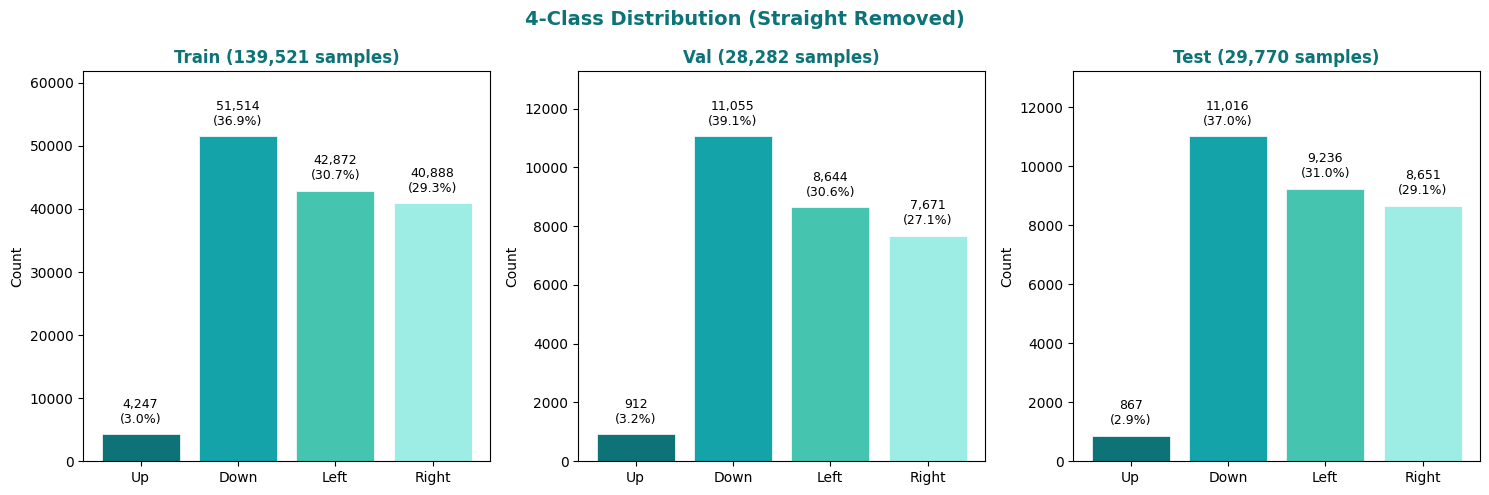

In [ ]:
# ============================================================
# CHECK CLASS BALANCE (per-split)
# ============================================================

label_names_map = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
teal_colors = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, loader) in zip(axes, [("train", train_loader), ("val", val_loader), ("test", test_loader)]):
    counts = {i: 0 for i in range(4)}
    total = 0
    for batch in loader:
        for lbl in batch['label'].tolist():
            counts[lbl] += 1
            total += 1

    class_names = [label_names_map[i] for i in range(4)]
    class_counts = [counts[i] for i in range(4)]
    bars = ax.bar(class_names, class_counts, color=teal_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{name.capitalize()} ({total:,} samples)', fontsize=12, fontweight='bold', color='#0D7377')
    ax.set_ylabel('Count')
    for bar, c in zip(bars, class_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{c:,}\n({100*c/total:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(class_counts) * 1.2)

    print(f"{name}: {total} samples, distribution: {counts}")

plt.suptitle('4-Class Distribution (Straight Removed)', fontsize=14, fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

## Test Pipeline

In [ ]:
# ============================================================
# SMOKE TEST: Run one batch through the full pipeline
# ============================================================

test_tar = [train_tar_urls[0]]
print(f"Testing with: {test_tar[0]}")

test_ds = make_dataset_4class(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))

print(f"\nBatch contents:")
print(f"  left_eye:     {batch['left_eye'].shape}")
print(f"  right_eye:    {batch['right_eye'].shape}")
print(f"  face:         {batch['face'].shape}")
print(f"  geo_features: {batch['geo_features'].shape}")
print(f"  label:        {batch['label'].shape}")
print(f"  label values: {batch['label'].tolist()}  (should be 0-3, no 4s)")

model.eval()
with torch.no_grad():
    outputs = model(
        batch['left_eye'].to(device),
        batch['right_eye'].to(device),
        batch['face'].to(device),
        batch['geo_features'].to(device),
    )

print(f"\nModel output: {outputs.shape}  <-- should be [4, 4]")
print(f"Pipeline works end-to-end!")

Testing with: /content/gaze_wds_balanced/train/gaze-train-000000.tar

Batch contents:
  left_eye:     torch.Size([4, 3, 48, 48])
  right_eye:    torch.Size([4, 3, 48, 48])
  face:         torch.Size([4, 3, 112, 112])
  geo_features: torch.Size([4, 7])
  label:        torch.Size([4])
  label values: [1, 1, 1, 1]  (should be 0-3, no 4s)

Model output: torch.Size([4, 4])  <-- should be [4, 4]
Pipeline works end-to-end!


## Train Model

In [ ]:
# ============================================================
# m5c TRAINING LOOP — Simple early stopping, no CNN freeze
#
# Class weights handle the Up imbalance. CNN trains throughout
# so it can adapt features to the weighted loss landscape.
# ============================================================

num_epochs = 20
best_val_loss = float('inf')

patience = 6
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # ============================================
    # CHECKPOINT: Save best model
    # ============================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # ============================================
    # EARLY STOPPING
    # ============================================
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1/20
  Batch 1000/~7000 - Loss: 0.8458 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.7444 - ETA: 11.4 min
  Batch 3000/~7000 - Loss: 0.7116 - ETA: 8.9 min
  Batch 4000/~7000 - Loss: 0.6627 - ETA: 6.5 min

  Time: 9.6 min
  Train Loss: 0.8120 | Train Acc: 84.50%
  Val Loss:   0.7042 | Val Acc:   90.33%
  Gap: -5.84%
  Saved best model (val_loss=0.7042)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.5165 - ETA: 13.4 min
  Batch 2000/~7000 - Loss: 0.6546 - ETA: 11.3 min
  Batch 3000/~7000 - Loss: 0.7773 - ETA: 8.8 min
  Batch 4000/~7000 - Loss: 0.5590 - ETA: 6.4 min

  Time: 9.5 min
  Train Loss: 0.6533 | Train Acc: 93.19%
  Val Loss:   0.6807 | Val Acc:   90.83%
  Gap: 2.36%
  Saved best model (val_loss=0.6807)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.6313 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.5584 - ETA: 11.3 min
  Batch 3000/~7000 - Loss: 0.5816 - ETA: 8.8 min
  Batch 4000/~7000 - Loss: 0.5619 - ETA: 6.5 min

  Time: 9.6 min
  Train Loss: 0.6147 | Train Acc: 94.83%
  Val Loss:  

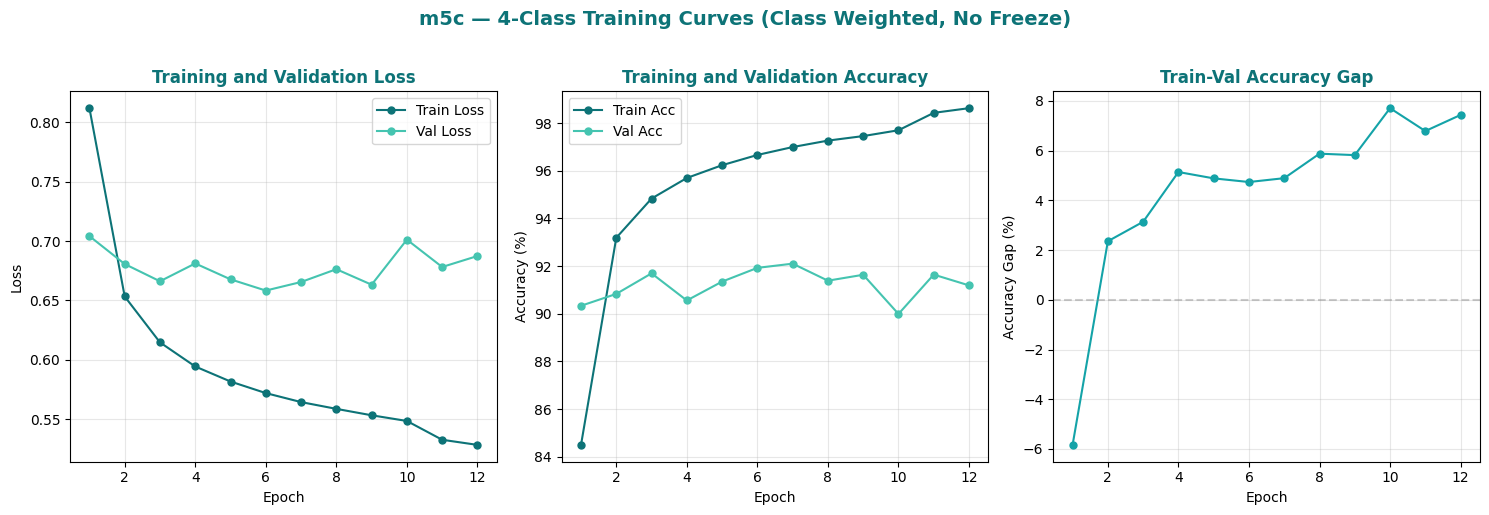


Training Summary
Total epochs completed: 12
Best validation loss: 0.6583 (Epoch 6)
Best validation accuracy: 92.10% (Epoch 7)
Final train accuracy: 98.63%
Final val accuracy: 91.19%
Final train-val gap: 7.44%


In [ ]:
# ============================================================
# LOSS CURVES — Teal theme
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Class Weighted, No Freeze)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

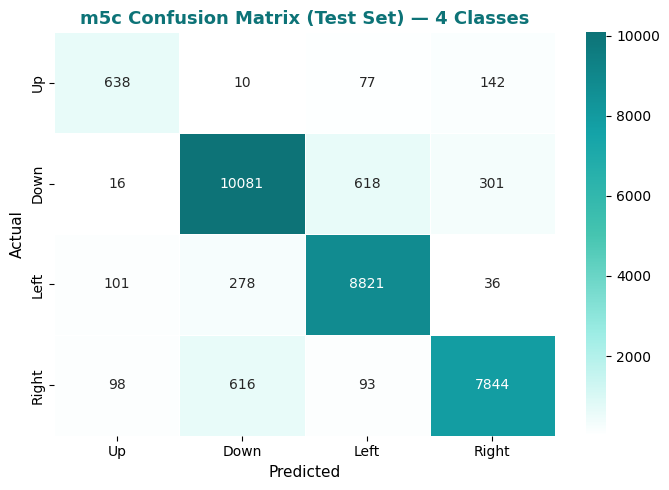


m5c Test Set Performance
              precision    recall  f1-score   support

          Up       0.75      0.74      0.74       867
        Down       0.92      0.92      0.92     11016
        Left       0.92      0.96      0.94      9236
       Right       0.94      0.91      0.92      8651

    accuracy                           0.92     29770
   macro avg       0.88      0.88      0.88     29770
weighted avg       0.92      0.92      0.92     29770



In [ ]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX — 4 classes, teal theme
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- 4-class labels ----
label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

# ---- Teal colormap ----
teal_cmap = LinearSegmentedColormap.from_list('teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

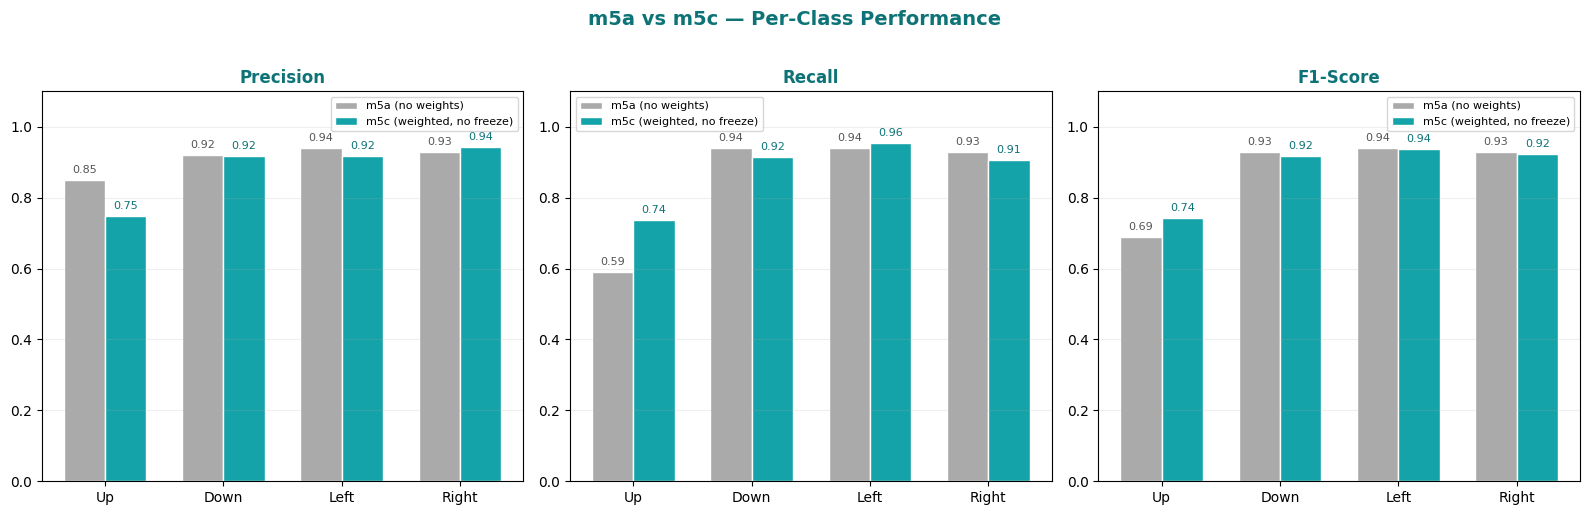


Per-Class Delta: m5c minus m5a (positive = m5c better)
Class      Prec Δ   Recall Δ     F1 Δ
------------------------------------------------------------
Up          -0.10      +0.15    +0.05
Down        -0.00      -0.02    -0.01
Left        -0.02      +0.02    -0.00
Right       +0.01      -0.02    -0.01


In [ ]:
# ============================================================
# m5a vs m5c COMPARISON
# ============================================================
# Hardcoded m5a results for comparison.
# ============================================================

m5a_report = {
    'Up':    {'precision': 0.85, 'recall': 0.59, 'f1': 0.69, 'support': 867},
    'Down':  {'precision': 0.92, 'recall': 0.94, 'f1': 0.93, 'support': 11016},
    'Left':  {'precision': 0.94, 'recall': 0.94, 'f1': 0.94, 'support': 9236},
    'Right': {'precision': 0.93, 'recall': 0.93, 'f1': 0.93, 'support': 8651},
}

# Get m5c per-class from the classification report
from sklearn.metrics import precision_recall_fscore_support
p, r, f, s = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])

# ---- Comparison bar chart ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(4)
width = 0.35

for ax, metric, m5a_key, m5c_vals, title in [
    (axes[0], 'precision', 'precision', p, 'Precision'),
    (axes[1], 'recall',    'recall',    r, 'Recall'),
    (axes[2], 'f1',        'f1',        f, 'F1-Score'),
]:
    m5a_vals = [m5a_report[c][m5a_key] for c in label_names]
    bars1 = ax.bar(x - width/2, m5a_vals, width, label='m5a (no weights)', color='#AAAAAA', edgecolor='white')
    bars2 = ax.bar(x + width/2, m5c_vals, width, label='m5c (weighted, no freeze)', color='#14A3A8', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight='bold', color='#0D7377')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#555555')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#0D7377')

plt.suptitle('m5a vs m5c — Per-Class Performance', fontsize=14, fontweight='bold', color='#0D7377', y=1.02)
plt.tight_layout()
plt.show()

# ---- Delta table ----
print("\n" + "="*60)
print("Per-Class Delta: m5c minus m5a (positive = m5c better)")
print("="*60)
print(f"{'Class':8s} {'Prec Δ':>8s} {'Recall Δ':>10s} {'F1 Δ':>8s}")
print("-"*60)
for i, name in enumerate(label_names):
    dp = p[i] - m5a_report[name]['precision']
    dr = r[i] - m5a_report[name]['recall']
    df = f[i] - m5a_report[name]['f1']
    print(f"{name:8s} {dp:>+8.2f} {dr:>+10.2f} {df:>+8.2f}")
print("="*60)

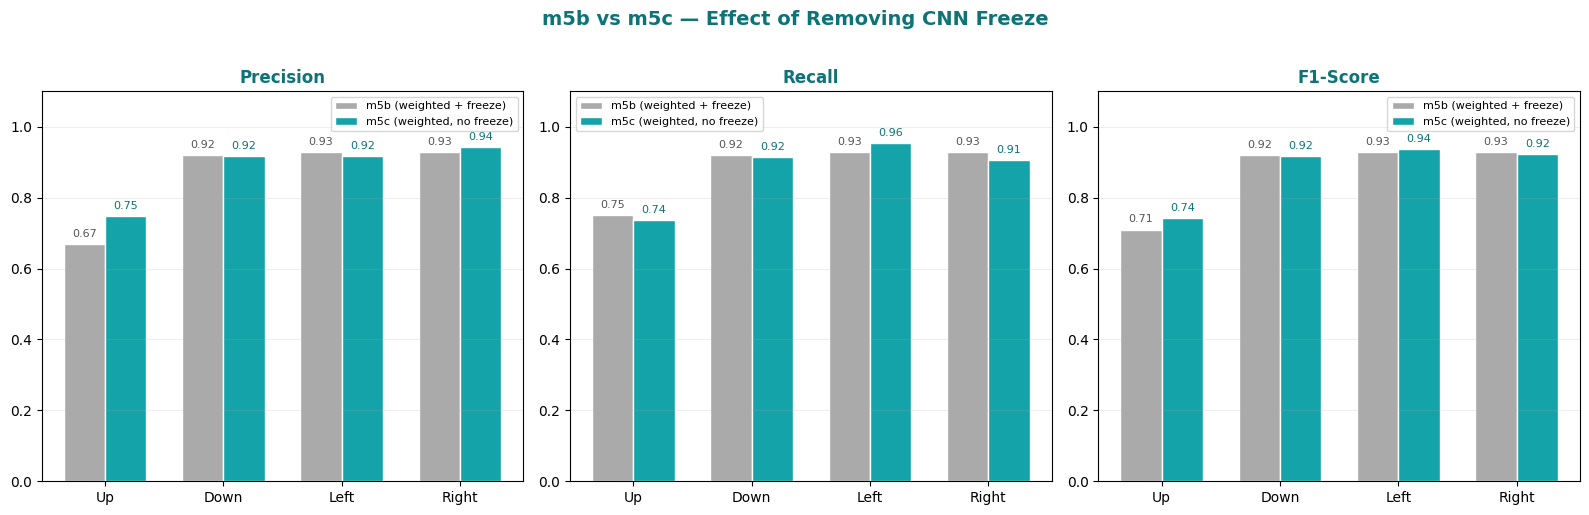


Per-Class Delta: m5c minus m5b (positive = m5c better)
Class      Prec Δ   Recall Δ     F1 Δ
------------------------------------------------------------
Up          +0.08      -0.01    +0.03
Down        -0.00      -0.00    -0.00
Left        -0.01      +0.03    +0.01
Right       +0.01      -0.02    -0.01


In [ ]:
# ============================================================
# m5b vs m5c COMPARISON
# ============================================================
# Hardcoded m5b results. Isolates the effect of removing
# the CNN freeze while keeping class weights.
# ============================================================

m5b_report = {
    'Up':    {'precision': 0.67, 'recall': 0.75, 'f1': 0.71, 'support': 867},
    'Down':  {'precision': 0.92, 'recall': 0.92, 'f1': 0.92, 'support': 11016},
    'Left':  {'precision': 0.93, 'recall': 0.93, 'f1': 0.93, 'support': 9236},
    'Right': {'precision': 0.93, 'recall': 0.93, 'f1': 0.93, 'support': 8651},
}

# ---- Comparison bar chart ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(4)
width = 0.35

for ax, metric, key, m5c_vals, title in [
    (axes[0], 'precision', 'precision', p, 'Precision'),
    (axes[1], 'recall',    'recall',    r, 'Recall'),
    (axes[2], 'f1',        'f1',        f, 'F1-Score'),
]:
    m5b_vals = [m5b_report[c][key] for c in label_names]
    bars1 = ax.bar(x - width/2, m5b_vals, width, label='m5b (weighted + freeze)', color='#AAAAAA', edgecolor='white')
    bars2 = ax.bar(x + width/2, m5c_vals, width, label='m5c (weighted, no freeze)', color='#14A3A8', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight='bold', color='#0D7377')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#555555')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#0D7377')

plt.suptitle('m5b vs m5c — Effect of Removing CNN Freeze', fontsize=14, fontweight='bold', color='#0D7377', y=1.02)
plt.tight_layout()
plt.show()

# ---- Delta table ----
print("\n" + "="*60)
print("Per-Class Delta: m5c minus m5b (positive = m5c better)")
print("="*60)
print(f"{'Class':8s} {'Prec Δ':>8s} {'Recall Δ':>10s} {'F1 Δ':>8s}")
print("-"*60)
for i, name in enumerate(label_names):
    dp = p[i] - m5b_report[name]['precision']
    dr = r[i] - m5b_report[name]['recall']
    df = f[i] - m5b_report[name]['f1']
    print(f"{name:8s} {dp:>+8.2f} {dr:>+10.2f} {df:>+8.2f}")
print("="*60)

In [ ]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINT
# ============================================================

print("train_losses_m5c =", train_losses)
print("val_losses_m5c =", val_losses)
print("train_acc_m5c =", train_accuracies)
print("val_acc_m5c =", val_accuracies)

import os
print(f"\nCheckpoint exists: {os.path.exists(CHECKPOINT_PATH)}")
print(f"Size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB")

train_losses_m5c = [0.8119657339100662, 0.6533410661511945, 0.6146887101402143, 0.5943828028253229, 0.5817236840260245, 0.5719863340631042, 0.5644072491117804, 0.5586943424259186, 0.553295024031484, 0.5484996645159744, 0.5326650714866067, 0.5283544815357495]
val_losses_m5c = [0.7042028013595754, 0.6806879599047246, 0.6661611421296826, 0.6811815809563728, 0.6677970519173617, 0.6583361093270577, 0.6655390130597992, 0.6763349390636056, 0.6632756286590112, 0.7012312029041139, 0.6781952198952604, 0.6874267592605224]
train_acc_m5c = [84.49552397130181, 93.18740548017861, 94.83231914908866, 95.69598841751422, 96.23282516610402, 96.66215121737946, 96.99400090308986, 97.2649278603221, 97.45486342557751, 97.6992710774722, 98.42962708122792, 98.62601328832218]
val_acc_m5c = [90.33307404002545, 90.83162435471324, 91.69436390637155, 90.55583056360936, 91.34785375857436, 91.92419206562478, 92.10098295735804, 91.38674775475567, 91.63425500318223, 89.99009971006294, 91.64132663885157, 91.1887419560144